# Analyze Sweep Results

This notebook inspects the parameter sweep results from `to_export/train_sweep.py`.

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

SWEEP_CSV = Path("../outputs/to_export_sweep/sweep_results.csv")
assert SWEEP_CSV.exists(), f"Missing sweep file: {SWEEP_CSV}"

sweep = pd.read_csv(SWEEP_CSV)
sweep.shape

(79, 12)

In [1]:
sweep.head()

NameError: name 'sweep' is not defined

In [ ]:
sweep.sort_values("test_mse").head(10)

,run_dir,model_type,loss_type,scaler_type,seed,test_mse,train_epochs,train_batch_train,train_batch_eval,train_lr,train_weight_decay,train_use_lr_scheduler
71,outputs/to_export_sweep/MTLGSH_KAN__huber__min...,MTLGSH_KAN,huber,minmax,42,0.000521,200,64,128,0.0005,0.00001,False
67,outputs/to_export_sweep/MTLGSH_KAN__smooth_l1_...,MTLGSH_KAN,smooth_l1,minmax,42,0.000521,200,64,128,0.0005,0.00001,False
39,outputs/to_export_sweep/MTLGSH_KAN_SHARED__mse...,MTLGSH_KAN_SHARED,mse,minmax,42,0.000527,200,64,128,0.0005,0.00001,False
63,outputs/to_export_sweep/MTLGSH_KAN__l1__minmax...,MTLGSH_KAN,l1,minmax,42,0.000530,200,64,128,0.0005,0.00001,False
7,outputs/to_export_sweep/MTLGSH__smooth_l1__min...,MTLGSH,smooth_l1,minmax,42,0.000572,200,64,128,0.0005,0.00001,False
11,outputs/to_export_sweep/MTLGSH__huber__minmax_...,MTLGSH,huber,minmax,42,0.000572,200,64,128,0.0005,0.00001,False
75,outputs/to_export_sweep/MTLGSH_KAN__kendall__m...,MTLGSH_KAN,kendall,minmax,42,0.000637,200,64,128,0.0005,0.00001,False
15,outputs/to_export_sweep/MTLGSH__kendall__minma...,MTLGSH,kendall,minmax,42,0.000695,200,64,128,0.0005,0.00001,False
59,outputs/to_export_sweep/MTLGSH_KAN__mse__minma...,MTLGSH_KAN,mse,minmax,42,0.000740,200,64,128,0.0005,0.00001,False
43,outputs/to_export_sweep/MTLGSH_KAN_SHARED__l1_...,MTLGSH_KAN_SHARED,l1,minmax,42,0.000743,200,64,128,0.0005,0.00001,False


In [ ]:
model_perf = sweep.groupby("model_type")["test_mse"].mean().sort_values()
model_perf

model_type
MTLGSH_ATT           0.019231
MTLGSH               0.021872
MTLGSH_KAN_SHARED    0.055989
MTLGSH_KAN           0.060657
Name: test_mse, dtype: float64

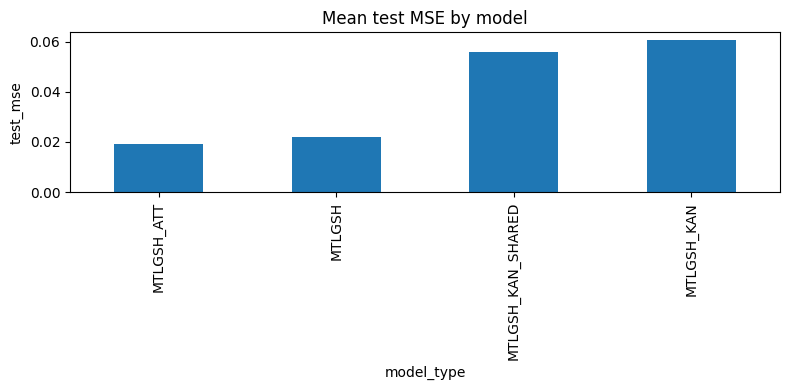

In [ ]:
model_perf.plot(kind="bar", figsize=(8, 4), title="Mean test MSE by model")
plt.ylabel("test_mse")
plt.tight_layout()

In [ ]:
loss_perf = sweep.groupby("loss_type")["test_mse"].mean().sort_values()
loss_perf

loss_type
kendall      0.039044
l1           0.039462
huber        0.039618
smooth_l1    0.039618
mse          0.040614
Name: test_mse, dtype: float64

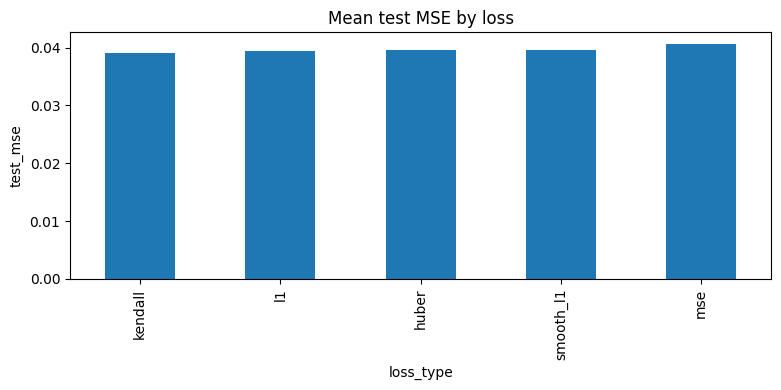

In [ ]:
loss_perf.plot(kind="bar", figsize=(8, 4), title="Mean test MSE by loss")
plt.ylabel("test_mse")
plt.tight_layout()